# 🩺 HealthBot — Patient Health Education Assistant

A LangGraph workflow that lets a patient pick a health topic, reads a Tavily-sourced,
patient-friendly summary, takes a one-question comprehension check, and gets a graded,
citation-backed explanation — looping to a new topic or exiting on request.

Patient interaction runs entirely in this notebook: `input()` for prompts, `print()` for
output, per the project's interface requirement. See `README.md` for the reasoning behind
this and other design choices (no `interrupt()`, no long-term memory, no RAG).

## 1. Setup: imports & environment variables

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama
# from langchain_openai import ChatOpenAI   # <- use this for the graded submission
from tavily import TavilyClient
from dotenv import load_dotenv
import os
import re
import difflib

In [3]:
# Load API keys from config.env (place this file alongside the notebook)
load_dotenv('config.env')

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

assert TAVILY_API_KEY is not None, "TAVILY_API_KEY not found — check config.env"
assert OPENAI_API_KEY is not None, "OPENAI_API_KEY not found — check config.env"

## 2. State schema & structured-output models

In [4]:
class State(TypedDict):
    user_input: str
    topic: str
    search_query: str
    search_results: list[dict]
    summary: str
    ready_check: int
    ready_choice: str
    question: str
    user_answer: str
    llm_grade: str
    explanation: str
    continue_choice: str


class TopicParser(BaseModel):
    topic: str = Field(description="Topic given by the user")
    query: str = Field(description="Search query generated by the model")


class Grader(BaseModel):
    llm_grade: str = Field(description="Grade provided by the model based on the user's answer")
    description: str = Field(description="Explanation provided by the model for the grade given")


# ChatOllama is used here for cost-free development. Swap for:
#   llm = ChatOpenAI(model="gpt-4o-mini")
# before the graded run — see README.md for why.
llm = ChatOllama(model="llama3.1")

## 3. Display helpers

Small formatting utilities built on top of `print()` so the summary, question, and grade
read clearly in a plain notebook cell — no external UI framework, per the project's
input/output requirement.

In [5]:
def print_banner(title: str, char: str = "=", width: int = 70) -> None:
    print(char * width)
    print(title.center(width))
    print(char * width)


def print_summary(summary: str) -> None:
    print("\n" + "=" * 70)
    print("📋  HEALTH SUMMARY".center(70))
    print("=" * 70)
    print(f"\n{summary}\n")
    print("=" * 70)


def print_question(question: str) -> None:
    print("\n" + "-" * 70)
    print("🧠  COMPREHENSION CHECK".center(70))
    print("-" * 70)
    print(f"\n{question}\n")
    print("-" * 70)


def print_grade(grade: str, explanation: str) -> None:
    emoji = {"CORRECT": "✅", "PARTIALLY CORRECT": "⚠️", "INCORRECT": "❌"}.get(grade.strip().upper(), "📊")
    print("\n" + "=" * 70)
    print(f"{emoji}  RESULT: {grade.strip().upper()}".center(70))
    print("=" * 70)
    print(f"\n{explanation}\n")
    print("=" * 70)

## 4. Citation verification helpers

The grading prompt requires a verbatim quote from the summary, but LLMs don't always
comply exactly. These helpers check the model's quote against the actual summary text
and supply a real fallback citation if it doesn't match — used inside `grade_node`.

In [6]:
def extract_quotes(text: str) -> list[str]:
    """Pulls out anything wrapped in double quotes."""
    return re.findall(r'"([^"]+)"', text)


def normalize(text: str) -> str:
    return " ".join(text.split()).lower()


def verify_citation(explanation: str, summary: str) -> bool:
    """True if at least one quoted span in `explanation` appears verbatim in `summary`."""
    norm_summary = normalize(summary)
    for quote in extract_quotes(explanation):
        if normalize(quote) and normalize(quote) in norm_summary:
            return True
    return False


def split_sentences(text: str) -> list[str]:
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]


def closest_sentence(query: str, summary: str) -> str:
    """Fallback: find the summary sentence most similar to the question/answer, for
    cases where the model still won't produce a verbatim quote after a retry."""
    sentences = split_sentences(summary)
    if not sentences:
        return summary[:150]
    matches = difflib.get_close_matches(query, sentences, n=1, cutoff=0.0)
    return matches[0] if matches else sentences[0]

## 5. Nodes

In [7]:
def get_topic_node(state: State) -> State:
    """
    Asks the patient which health topic they'd like to learn about today.
    """
    print_banner("🩺  Welcome to HealthBot")
    user_input = input(
        "What health topic or medical condition would you like to learn about today?\n> "
    )
    return {"user_input": user_input}

In [8]:
def extraction_node(state: State) -> State:
    """
    Parses the raw topic provided by the patient and normalizes it into a clean search query.
    """
    raw_topic = state["user_input"]
    prompt = f"""
        You are a medical data extraction assistant. Your task is to extract the core medical, health, or anatomical topic from the user's raw input and normalize it into a highly specific search query.

        Raw input: "{raw_topic}"

        Instructions:
        1. Correct any spelling or medical terminology errors.
        2. Strip away conversational filler (e.g., "Tell me about...", "I want to know...").
        3. If the input is too vague, formulate it into a standard medical search query.
        4. Output ONLY the normalized search query string. Do not include quotes, explanations, or introductory text.
    """
    response = llm.with_structured_output(TopicParser).invoke(prompt)
    return {
        "topic": response.topic,
        "search_query": response.query,
    }

In [9]:
def search_tavily_node(state: State) -> State:
    """
    Searches Tavily for reputable, up-to-date information on the topic.
    """
    print("🔎 Looking up reliable medical information on your topic...")
    client = TavilyClient(api_key=TAVILY_API_KEY)
    search_query = state["search_query"]
    response = client.search(query=search_query, search_depth="advanced")
    return {"search_results": response["results"]}

In [10]:
def summary_node(state: State) -> State:
    """
    Summarizes the Tavily search results into a patient-friendly explanation.
    """
    print("📝 Putting together an easy-to-understand summary...")
    search_results = state["search_results"]
    results_text = "\n".join(
        [f"Title: {r['title']} \nURL: {r['url']} \nSnippet: {r['content']}" for r in search_results]
    )
    prompt = f"""
        You are a knowledgeable and empathetic medical educator. Your task is to write a patient-friendly summary based STRICTLY on the provided search results.
        Search Results:
        {results_text}

        Instructions:
        1. Write exactly 3 to 4 paragraphs.
        2. Use simple, patient-friendly language (aim for an 8th-grade reading level). Avoid heavy medical jargon, or explain it simply if it must be used.
        3. Base your summary ONLY on the provided search results. Do not include outside knowledge or information not found in the text above.
        4. Do not offer medical advice or diagnoses. Frame it as educational information.
    """
    response = llm.invoke(prompt)
    return {"summary": response.content}

In [11]:
def present_summary_node(state: State) -> State:
    """
    Presents the summary to the patient.
    """
    print_summary(state["summary"])
    return {}

In [12]:
def ready_check_node(state: State) -> State:
    """
    Asks the patient if they're ready for the comprehension check. I/O and state update
    only — routing is handled separately by route_ready() below, so this never fires twice.
    """
    ready_count = state.get("ready_check", 0)
    if ready_count == 0:
        ready_input = input(
            "\n📖 Take a moment to read through the summary above.\n"
            "Are you ready to test your understanding with a quick question? (yes/no): "
        )
    else:
        ready_input = input(
            "⏳ No rush at all — take your time.\n"
            "Ready to continue now? (yes/no): "
        )

    ready_choice = ready_input.strip().lower()
    if ready_choice not in ["yes", "y"]:
        print("👍 No problem — review the summary above whenever you're ready.")

    return {"ready_choice": ready_choice, "ready_check": ready_count + 1}


def route_ready(state: State) -> Literal["generate_question_node", "ready_check_node"]:
    """
    Pure routing function: no I/O, no state mutation — just reads state and returns
    the next node's name.
    """
    if state["ready_choice"] in ["yes", "y"]:
        return "generate_question_node"
    return "ready_check_node"

In [13]:
def generate_question_node(state: State) -> State:
    """
    Generates a single comprehension-check question, answerable from the summary alone.
    """
    print("🧠 Preparing your comprehension check...")
    summary = state["summary"]
    prompt = f"""
    You are a helpful study tutor. Your task is to generate exactly ONE question to test the user's understanding of the medical summary they just read.
    Summary:
    {summary}

    Instructions:
    1. Generate exactly one clear, concise question.
    2. The question MUST be fully answerable using ONLY the information provided in the summary above.
    3. Do not ask overly broad questions or trivial formatting questions; focus on a key concept, symptom, cause, or treatment mentioned in the text.
    4. Output ONLY the question. Do not include the answer, multiple-choice options, or introductory text.
    """
    response = llm.invoke(prompt)
    return {"question": response.content}

In [14]:
def present_question_node(state: State) -> State:
    """
    Presents the generated question to the patient.
    """
    print_question(state["question"])
    return {}

In [15]:
def get_answer_node(state: State) -> State:
    """
    Collects the patient's answer to the quiz question.
    """
    user_answer = input("✍️  Your answer: ")
    return {"user_answer": user_answer}

In [16]:
def grade_node(state: State) -> State:
    """
    Grades the patient's answer using only the summary as a source. Requires a verbatim
    citation from the summary; verifies it programmatically, retries once if the model's
    quote doesn't actually match, and falls back to a real extracted citation if it still
    doesn't comply.
    """
    print("🔍 Grading your answer...")
    summary = state["summary"]
    question = state["question"]
    user_answer = state["user_answer"]

    def build_prompt(strict: bool = False) -> str:
        extra = ""
        if strict:
            extra = (
                "\nIMPORTANT: Your previous quote did not match the summary text exactly. "
                "Copy a short span character-for-character from the Context Summary above, "
                "including punctuation, and wrap it in quotation marks."
            )
        return f"""
        You are a strict but fair grader assessing a user's answer to a medical quiz question.
        Context Summary:
        {summary}

        Question Asked:
        {question}

        User's Answer:
        {user_answer}

        Instructions:
        1. Evaluate the user's answer based STRICTLY on the Context Summary provided above.
        2. Assign a grade: CORRECT, PARTIALLY CORRECT, or INCORRECT.
        3. Provide a brief justification for your grade.
        4. You MUST include at least one direct, verbatim quote from the Context Summary to support your justification. Wrap the quote in quotation marks.
        5. Do not use outside knowledge. If the user's answer is factually true in the real world but contradicts or is missing from the Context Summary, grade it based ONLY on the summary.{extra}
        """

    response = llm.with_structured_output(Grader).invoke(build_prompt())
    if not verify_citation(response.description, summary):
        response = llm.with_structured_output(Grader).invoke(build_prompt(strict=True))

    explanation = response.description
    if not verify_citation(explanation, summary):
        fallback_quote = closest_sentence(f"{question} {user_answer}", summary)
        explanation += f'\n\n(Reference from summary: "{fallback_quote}")'

    return {"llm_grade": response.llm_grade, "explanation": explanation}

In [17]:
def present_grade_node(state: State) -> State:
    """
    Presents the grade and citation-backed explanation to the patient.
    """
    print_grade(state["llm_grade"], state["explanation"])
    return {}

In [18]:
def continue_check_node(state: State) -> State:
    """
    Asks the patient if they want to explore another topic. I/O only — routing
    is handled separately by route_continue() below.
    """
    continue_input = input(
        "\n🔄 Would you like to explore another health topic, or are you finished for today? (yes/no): "
    )
    return {"continue_choice": continue_input.strip().lower()}


def route_continue(state: State) -> Literal["reset_node", "__end__"]:
    """
    Pure routing function.
    """
    if state["continue_choice"] in ["yes", "y"]:
        return "reset_node"
    print_banner("👋  Thanks for using HealthBot — take care!")
    return END

In [19]:
def reset_node(state: State) -> State:
    """
    Clears all topic-specific state before starting a new topic, so previous
    health information isn't carried over (patient privacy + accuracy).
    """
    print("\n🔄 Starting a new topic — your previous topic's data has been cleared.\n")
    return {
        "user_input": "",
        "topic": "",
        "search_query": "",
        "search_results": [],
        "summary": "",
        "ready_check": 0,
        "ready_choice": "",
        "question": "",
        "user_answer": "",
        "llm_grade": "",
        "explanation": "",
        "continue_choice": "",
    }

## 6. Build the graph

In [20]:
builder = StateGraph(State)

builder.add_node("get_topic_node", get_topic_node)
builder.add_node("extraction_node", extraction_node)
builder.add_node("search_tavily_node", search_tavily_node)
builder.add_node("summary_node", summary_node)
builder.add_node("present_summary_node", present_summary_node)
builder.add_node("ready_check_node", ready_check_node)
builder.add_node("generate_question_node", generate_question_node)
builder.add_node("present_question_node", present_question_node)
builder.add_node("get_answer_node", get_answer_node)
builder.add_node("grade_node", grade_node)
builder.add_node("present_grade_node", present_grade_node)
builder.add_node("continue_check_node", continue_check_node)
builder.add_node("reset_node", reset_node)

builder.add_edge(START, "get_topic_node")
builder.add_edge("get_topic_node", "extraction_node")
builder.add_edge("extraction_node", "search_tavily_node")
builder.add_edge("search_tavily_node", "summary_node")
builder.add_edge("summary_node", "present_summary_node")
builder.add_edge("present_summary_node", "ready_check_node")

builder.add_conditional_edges("ready_check_node", route_ready, {
    "generate_question_node": "generate_question_node",
    "ready_check_node": "ready_check_node",
})

builder.add_edge("generate_question_node", "present_question_node")
builder.add_edge("present_question_node", "get_answer_node")
builder.add_edge("get_answer_node", "grade_node")
builder.add_edge("grade_node", "present_grade_node")
builder.add_edge("present_grade_node", "continue_check_node")

builder.add_conditional_edges("continue_check_node", route_continue, {
    "reset_node": "reset_node",
    END: END,
})

builder.add_edge("reset_node", "get_topic_node")

graph = builder.compile()

## 7. Visualize the graph

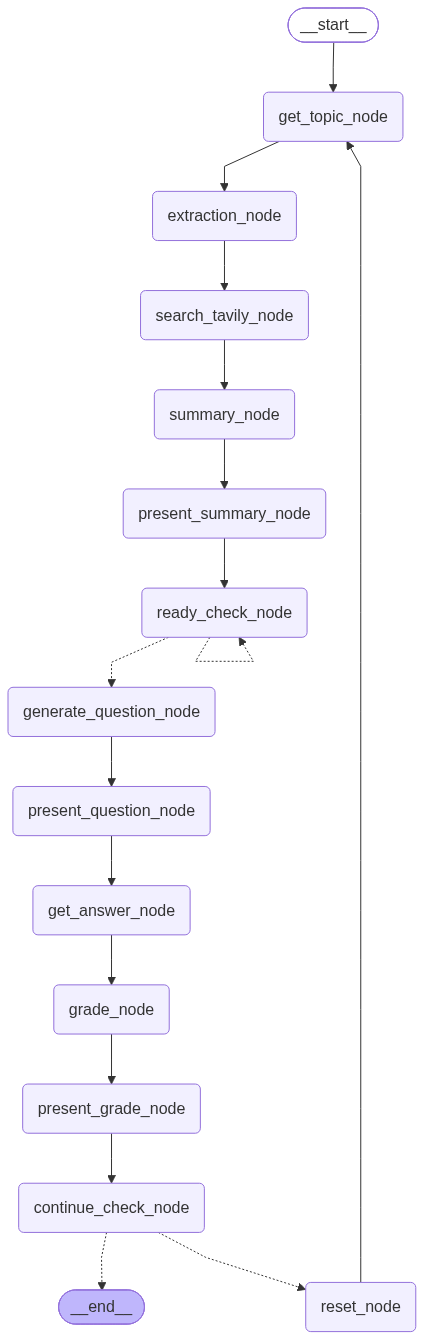

In [21]:
graph

## 8. Run the HealthBot

In [22]:
result = graph.invoke({}, config={"recursion_limit": 100})

                       🩺  Welcome to HealthBot                        
🔎 Looking up reliable medical information on your topic...
📝 Putting together an easy-to-understand summary...

                          📋  HEALTH SUMMARY                           

Here is a patient-friendly summary based on the provided search results:

**What is Diabetes?**

Diabetes is a disease that occurs when your blood glucose, also called blood sugar, is too high. Glucose is what gives you energy to live and work. If you have diabetes, your body either doesn't make enough insulin or can't use it properly. This causes glucose to build up in the blood instead of being used by the cells.

**Types of Diabetes**

There are three main types of diabetes: Type 1, Type 2, and Gestational. Type 1 diabetes is when the pancreas can't produce any insulin at all. Type 2 diabetes is more common and occurs when the body becomes resistant to insulin over time. Gestational diabetes develops during pregnancy due to high blo